<a href="https://colab.research.google.com/github/D2718281828nis/BioMedAI-Heart-Desease-LifeTime-Forecast/blob/main/XGboost-predictions-case1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[I 2026-07-30 12:13:55,073] A new study created in memory with name: no-name-3b78566c-5605-4c2a-bc74-87e317ff083f


Dataset loaded successfully.

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1506 entries, 0 to 1505
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   dmonit                1506 non-null   int64  
 1   0_no, 1_ther, 2_card  1506 non-null   int64  
 2   card                  1506 non-null   int64  
 3   time                  1506 non-null   int64  
 4   result                1506 non-null   int64  
 5   age                   1506 non-null   float64
 6   result_cvd            1506 non-null   int64  
 7   af                    1506 non-null   int64  
 8   dm                    1506 non-null   int64  
 9   ckd                   1506 non-null   int64  
 10  copd                  1506 non-null   int64  
 11  insult                1506 non-null   int64  
 12  onco                  1506 non-null   int64  
 13  0_na, 1_mi            1506 non-null   int64  
 14  na                   

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-30 12:13:56,912] Trial 0 finished with value: 327.42188578239956 and parameters: {'booster': 'dart', 'n_estimators': 746, 'learning_rate': 0.058006322999333615, 'max_depth': 4, 'min_child_weight': 2, 'gamma': 0.02904180608409973, 'subsample': 0.9464704583099741, 'colsample_bytree': 0.8404460046972835, 'reg_alpha': 0.004619347374377372, 'reg_lambda': 1.4610865886287176e-08}. Best is trial 0 with value: 327.42188578239956.
[I 2026-07-30 12:13:57,545] Trial 1 finished with value: 316.39258616971773 and parameters: {'booster': 'gbtree', 'n_estimators': 251, 'learning_rate': 0.010526458851636467, 'max_depth': 4, 'min_child_weight': 4, 'gamma': 0.2623782158161189, 'subsample': 0.7727780074568463, 'colsample_bytree': 0.7164916560792167, 'reg_alpha': 0.000784915956255507, 'reg_lambda': 1.3060231803531604e-07}. Best is trial 1 with value: 316.39258616971773.
[I 2026-07-30 12:13:58,654] Trial 2 finished with value: 335.83682455949554 and parameters: {'booster': 'dart', 'n_estimators':

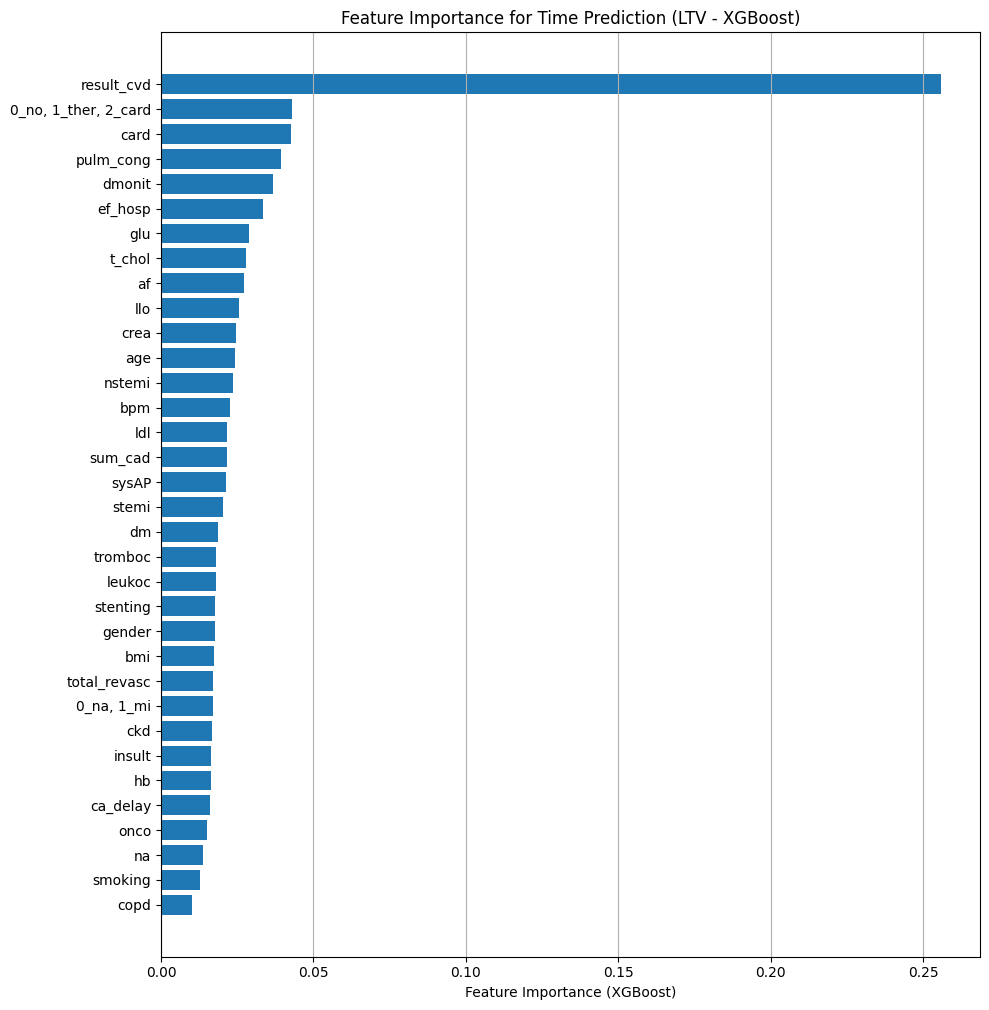


--- Top 5 Most Important Features (XGBoost) ---
             feature  importance
              dmonit    0.036639
           pulm_cong    0.039270
                card    0.042604
0_no, 1_ther, 2_card    0.042872
          result_cvd    0.255898

--- Sample Predictions Comparison (First 10 Test Samples - XGBoost) ---
   Actual_Time  Predicted_Time_XGB_Tuned
0         1310               1150.420044
1         1481               1355.060059
2         1314               1331.969971
3         1141               1159.140015
4          966               1175.410034
5         1404               1411.180054
6         1297               1121.810059
7           50                587.309998
8         1374               1137.660034
9         1299                877.239990


In [7]:
# --- Colab Setup ---
# Ensure necessary libraries are installed in the Colab environment
!pip install openpyxl scikit-learn pandas numpy matplotlib seaborn statsmodels lifelines xgboost optuna

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# Removed statsmodels related imports as LinearRegression diagnostics are being removed
# import statsmodels.api as sm
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from statsmodels.stats.diagnostic import het_breuschpagan
# from scipy.stats import shapiro # For normality check on residuals
import warnings
warnings.filterwarnings("ignore")

import optuna
import xgboost as xgb

# --- 1. Load Data ---
# Upload the Excel file to Colab first, then read it
# Replace 'path/to/your/file.xlsx' with the actual name of the uploaded file in Colab
try:
    # Example: df = pd.read_excel('/content/med_dataset_cardio.xlsx')
    # You need to upload the file and get its path
    # Let's assume the file is named 'med_dataset_cardio.xlsx' after upload
    df = pd.read_excel('/content/med_dataset_cardio.xlsx') # Adjust path as needed
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: File '/content/med_dataset_cardio.xlsx' not found. Please upload the file to Colab.")
    # Example of creating dummy data if file is not available
    # df = pd.DataFrame(np.random.rand(100, 10), columns=[f'var{i}' for i in range(10)])
    # df['time'] = np.random.rand(100) * 1000 + 100 # Example 'time' variable
    # print("Using example dummy data.")

print("\n--- Dataset Info ---")
print(df.info())
print("\n--- First few rows ---")
print(df.head())

# --- 2. Data Preprocessing for LTV Prediction (Time as Target) ---
# Assuming 'time' is the target variable representing lifetime value / follow-up time
target_column = 'time'

# Check for missing values in the target column and drop if any
missing_target_indices = df[df[target_column].isnull()].index
if len(missing_target_indices) > 0:
    print(f"\nFound {len(missing_target_indices)} rows with missing '{target_column}'. Dropping them.")
    df = df.drop(missing_target_indices)
    df.reset_index(drop=True, inplace=True)

# Define features (excluding 'time' and potentially 'result' if it's an outcome related to 'time')
# 'result' might be an event indicator (1=event, 0=censored) in survival analysis, not always used as a predictor for time directly if time is the target
feature_columns = [col for col in df.columns if col not in [target_column, 'result']] # Exclude 'result' too, often a dependent variable linked to time

X = df[feature_columns]
y = df[target_column]

# Handle missing values in features (if any remain after loading)
# Option 1: Drop rows with any missing features (be cautious if many NAs exist)
# X = X.dropna()
# y = y[X.index] # Align y with X

# Option 2: Fill missing values (more common)
X = X.fillna(X.median()) # Using median for robustness, especially if non-normal
# X = X.fillna(0) # Alternative: fill with 0

print(f"\nFeatures shape: {X.shape}, Target shape: {y.shape}")
print(f"Features used: {list(X.columns)}")

# --- 3. Split Data (IMPORTANT: Reset index here to ensure alignment) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.reset_index(drop=True, inplace=True) # Reset index for training set
y_train.reset_index(drop=True, inplace=True) # Reset index for training target
X_test.reset_index(drop=True, inplace=True)   # Reset index for test set
y_test.reset_index(drop=True, inplace=True)   # Reset index for test target


# --- 4. Scale Features (Important for many algorithms) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling if needed later (e.g., for VIF calculation)
# Ensure the scaled DataFrames have the same index as the original splits
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index) # Pass index explicitly
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)   # Pass index explicitly

# --- 5. Removed Linear Regression Model Training and Prediction ---

# --- 6. Removed Linear Regression Model Prediction ---

# --- 7. Evaluate Models (General Function) ---
def evaluate_model(y_true, y_pred, model_name):
    """Calculates and prints key regression metrics."""
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\n--- Evaluation Metrics for {model_name} ---")
    print(f"  R² (Coefficient of Determination): {r2:.4f}")
    print(f"  Mean Squared Error (MSE): {mse:.4f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"  Mean Absolute Error (MAE): {mae:.4f}")

# --- 8. Removed Linear Regression Diagnostics ---

# --- 9. Removed Residual Analysis for Linear Model ---

# --- 10. Removed Linear Regression Visualizations ---

# --- 11. Hyperparameter Tuning with Optuna (XGBoost Regressor) ---
print("\n--- Hyperparameter Tuning with Optuna for XGBoost Regressor ---")

def objective_xgb(trial):
    # Parameters based on the user's example, adapted for regression
    param = {
        'objective': 'reg:squarederror', # Changed from binary:logistic for regression
        'eval_metric': 'rmse',
        'booster': trial.suggest_categorical("booster", ['gbtree', 'dart']),
        'n_estimators': trial.suggest_int("n_estimators", 50, 1000),
        'learning_rate': trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        'max_depth': trial.suggest_int("max_depth", 3, 10),
        'min_child_weight': trial.suggest_int("min_child_weight", 1, 10),
        'gamma': trial.suggest_float("gamma", 0.0, 0.5),
        'subsample': trial.suggest_float("subsample", 0.6, 1.0),
        'colsample_bytree': trial.suggest_float("colsample_bytree", 0.6, 1.0),
        'reg_alpha': trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        'random_state': 42,
        'n_jobs': -1
    }

    # The provided example also had 'grow_policy', 'tree_method', 'max_bin', 'max_leaves',
    # 'colsample_bylevel', 'colsample_bynode', 'base_score'. These are more specific for
    # fine-tuning and can be added if initial results with this set are not sufficient.

    model = xgb.XGBRegressor(**param)

    # Use KFold for cross-validation for regression tasks
    # Using scaled data as specified in earlier steps
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_scores = []
    for train_idx, val_idx in kf.split(X_train_scaled, y_train):
        X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_pred_val = model.predict(X_val)
        rmse_scores.append(np.sqrt(mean_squared_error(y_val, y_pred_val)))

    return np.mean(rmse_scores)

# Create Optuna study
study_xgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True) # You can increase n_trials for better optimization

print("  Best trial for XGBoost:")
print(f"    Value (RMSE): {study_xgb.best_value:.4f}")
print(f"    Params: {study_xgb.best_params}")

# Train and evaluate XGBoost with best hyperparameters
xgb_model_tuned = xgb.XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1)
xgb_model_tuned.fit(X_train_scaled, y_train)
y_pred_xgb_tuned = xgb_model_tuned.predict(X_test_scaled)
evaluate_model(y_test, y_pred_xgb_tuned, "XGBoost Regressor (Tuned)")

# --- 12. Feature Importance (XGBoost) ---
feat_imp_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model_tuned.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, max(6, len(feat_imp_xgb) * 0.3)))
plt.barh(feat_imp_xgb['feature'], feat_imp_xgb['importance'])
plt.xlabel('Feature Importance (XGBoost)')
plt.title('Feature Importance for Time Prediction (LTV - XGBoost)')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

print("\n--- Top 5 Most Important Features (XGBoost) ---")
print(feat_imp_xgb.tail(5)[['feature', 'importance']].to_string(index=False))

# --- 13. Comparison Table of Predictions (Sample - Only XGBoost) ---
comparison_df_all = pd.DataFrame({
    'Actual_Time': y_test.values,
    'Predicted_Time_XGB_Tuned': y_pred_xgb_tuned
}).head(10)

print("\n--- Sample Predictions Comparison (First 10 Test Samples - XGBoost) ---")
print(comparison_df_all.round(2))

# Практический пример для патента

Categorization Threshold: Low Risk <= 1264.00, High Risk > 1264.00


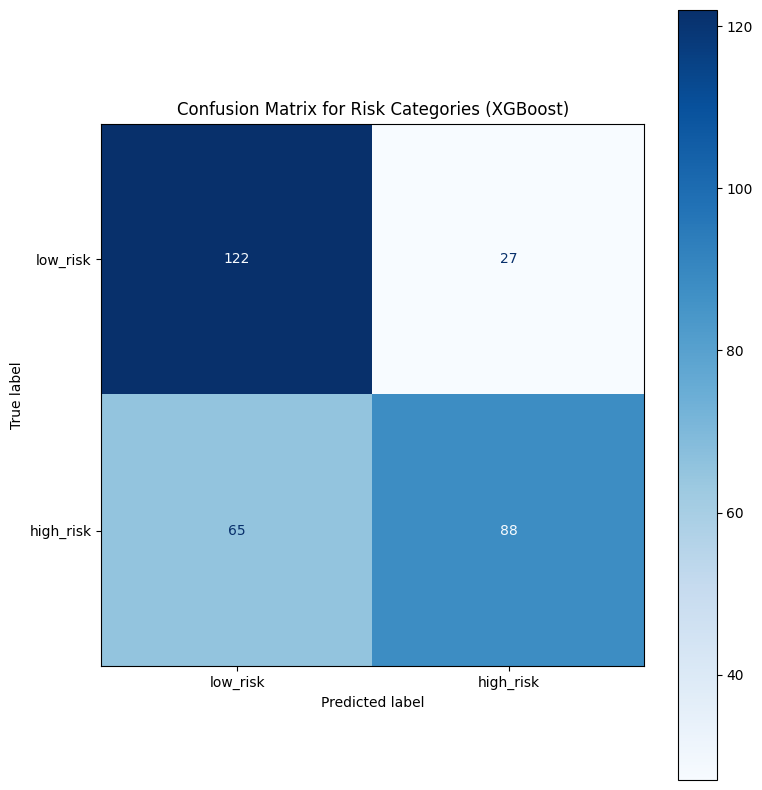


--- Categorized Risk Predictions (Sample) ---
  Actual_Risk_Category Predicted_Risk_Category_XGB
0            high_risk                    low_risk
1            high_risk                   high_risk
2            high_risk                   high_risk
3             low_risk                    low_risk
4             low_risk                    low_risk
5            high_risk                   high_risk
6            high_risk                    low_risk
7             low_risk                    low_risk
8            high_risk                    low_risk
9            high_risk                    low_risk


In [9]:
# --- 14. Convert Regression to Classification for Confusion Matrix ---
# This section categorizes the continuous 'time' variable into discrete bins
# to allow for the computation of a confusion matrix.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Define a single threshold for categorization for 'low_risk' and 'high_risk'.
# For demonstration, we'll use the median of the 'time' variable as the threshold.
# You can adjust this based on your domain knowledge or desired risk tolerance.

risk_threshold = y.median() # Using the median to split into two groups

print(f"Categorization Threshold: Low Risk <= {risk_threshold:.2f}, High Risk > {risk_threshold:.2f}")

def categorize_time_risk(time_value):
    if time_value <= risk_threshold:
        return 'low_risk'
    else:
        return 'high_risk'

# Apply categorization to actual and predicted values
y_test_category_risk = y_test.apply(categorize_time_risk)
y_pred_xgb_category_risk = pd.Series(y_pred_xgb_tuned).apply(categorize_time_risk)

# Compute Confusion Matrix
cm_risk = confusion_matrix(y_test_category_risk, y_pred_xgb_category_risk, labels=['low_risk', 'high_risk'])
disp_risk = ConfusionMatrixDisplay(confusion_matrix=cm_risk, display_labels=['low_risk', 'high_risk'])

fig_risk, ax_risk = plt.subplots(figsize=(8, 8))
disp_risk.plot(cmap=plt.cm.Blues, ax=ax_risk)
ax_risk.set_title('Confusion Matrix for Risk Categories (XGBoost)')
plt.tight_layout()
plt.show()

print("\n--- Categorized Risk Predictions (Sample) ---")
comparison_categorized_risk_df = pd.DataFrame({
    'Actual_Risk_Category': y_test_category_risk,
    'Predicted_Risk_Category_XGB': y_pred_xgb_category_risk
}).head(10)
print(comparison_categorized_risk_df)

### Case Studies: Survival Curve Analysis for High and Low Risk Patients
To demonstrate how the model can be used to assess individual patient outcomes, we will:
1.  Train a `CoxPHFitter` model from the `lifelines` library using the training data.
2.  Select two representative patients from the test set: one with a high predicted risk (and observed early event) and one with a low predicted risk (and observed late event).
3.  Plot their individual predicted survival curves using the trained `CoxPHFitter` model.

CoxPHFitter model trained successfully.

Case 1 Patient (Predicted High Risk, Actual Early Event) selected from test index: 24
  Actual Time: 1183.00, Actual Event: 1, Predicted Risk: high_risk
Case 2 Patient (Predicted Low Risk, Actual No Event) selected from test index: 0
  Actual Time: 1310.00, Actual Event: 0, Predicted Risk: low_risk


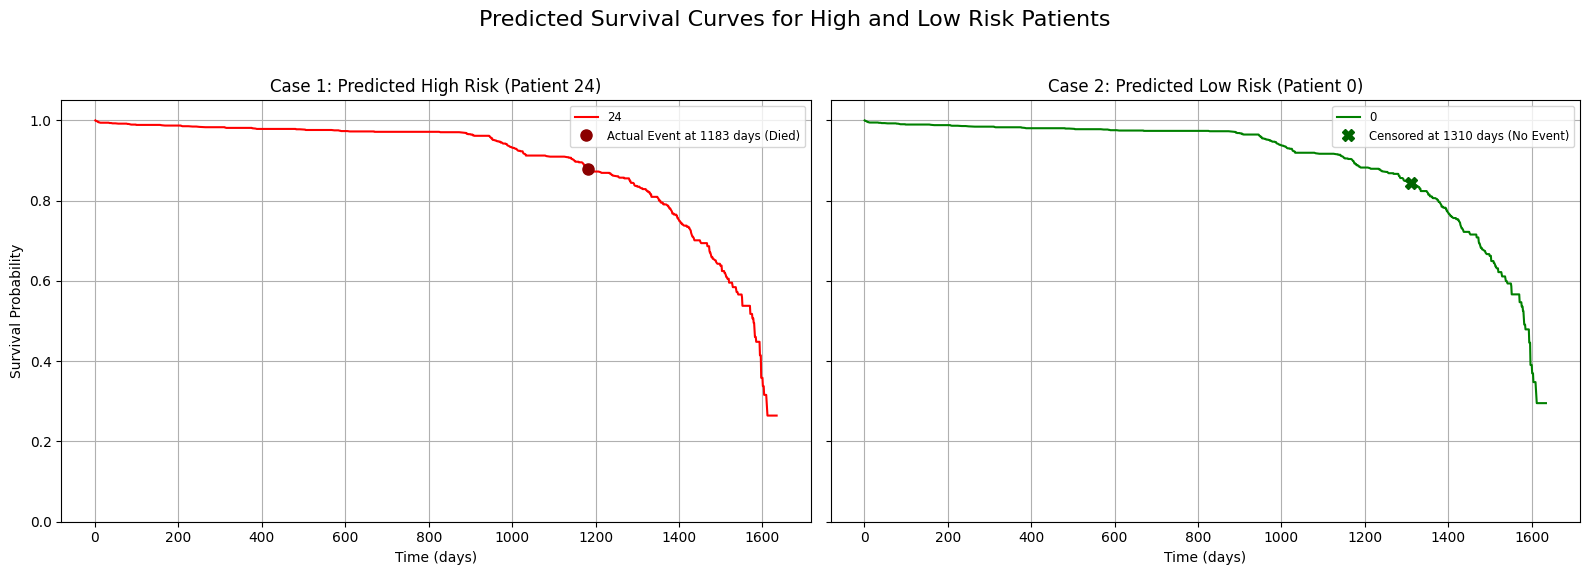

In [17]:
from lifelines import CoxPHFitter

# --- 1. Prepare data for CoxPHFitter and train the model ---
# The CoxPHFitter expects a DataFrame with event (result) and duration (time) columns,
# along with the features.

# Combine y_train (time), result (event indicator), and X_train_scaled_df (features)
# Assuming 'result' column exists in the original df and corresponds to y_train indices.
# We need to map the 'result' column back to the training set.

# Get 'result' for the training set (aligned with X_train/y_train)
result_train = df.loc[X_train.index, 'result']

df_train_survival = X_train_scaled_df.copy()
df_train_survival['duration'] = y_train.values # 'time' is mapped to 'duration'
df_train_survival['event'] = result_train.values  # 'result' is mapped to 'event'

# Initialize and fit the CoxPHFitter model
# Added a penalizer to address collinearity issues and help convergence.
# A small L2 penalizer (e.g., 0.1) is often a good starting point for stability.
cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_train_survival, duration_col='duration', event_col='event')

print("CoxPHFitter model trained successfully.")
# cph.print_summary() # Optional: print a summary of the fitted model

# --- 2. Select patients for Case 1 (High Risk, Early Event) and Case 2 (Low Risk, Late Event/No Event) ---
# We need to find specific patient indices from the test set.

# Get 'result' for the test set (aligned with X_test/y_test)
result_test = df.loc[X_test.index, 'result']

# Case 1: Predicted High Risk, Actual Early Event
# Find patients predicted as 'high_risk' by XGBoost,
# who actually had an event (result=1) AND their actual time was less than the risk threshold.
high_risk_early_event_candidates = X_test.index[
    (y_pred_xgb_category_risk == 'high_risk') &
    (result_test == 1) &
    (y_test < risk_threshold)
]

# Case 2: Predicted Low Risk, Actual No Event (patient live, not died)
# Find patients predicted as 'low_risk' by XGBoost,
# who actually did NOT have an event (result=0).
low_risk_no_event_candidates = X_test.index[
    (y_pred_xgb_category_risk == 'low_risk') &
    (result_test == 0)
]

# Select the first available patient from each category for demonstration
patient_idx_case1 = None
patient_idx_case2 = None

if not high_risk_early_event_candidates.empty:
    patient_idx_case1 = high_risk_early_event_candidates[0]
    print(f"\nCase 1 Patient (Predicted High Risk, Actual Early Event) selected from test index: {patient_idx_case1}")
    print(f"  Actual Time: {y_test.loc[patient_idx_case1]:.2f}, Actual Event: {result_test.loc[patient_idx_case1]}, Predicted Risk: {y_pred_xgb_category_risk.loc[patient_idx_case1]}")
else:
    print("\nCould not find a suitable patient for Case 1 (Predicted High Risk, Actual Early Event) in the test set.")

if not low_risk_no_event_candidates.empty:
    patient_idx_case2 = low_risk_no_event_candidates[0]
    print(f"Case 2 Patient (Predicted Low Risk, Actual No Event) selected from test index: {patient_idx_case2}")
    print(f"  Actual Time: {y_test.loc[patient_idx_case2]:.2f}, Actual Event: {result_test.loc[patient_idx_case2]}, Predicted Risk: {y_pred_xgb_category_risk.loc[patient_idx_case2]}")
else:
    print("Could not find a suitable patient for Case 2 (Predicted Low Risk, Actual No Event) in the test set.")


# --- 3. Predict and Plot Survival Curves ---

if patient_idx_case1 is not None and patient_idx_case2 is not None:
    # Extract scaled features for the selected patients
    patient_features_case1 = X_test_scaled_df.loc[[patient_idx_case1]]
    patient_features_case2 = X_test_scaled_df.loc[[patient_idx_case2]]

    # Predict survival functions
    survival_function_case1 = cph.predict_survival_function(patient_features_case1)
    survival_function_case2 = cph.predict_survival_function(patient_features_case2)

    # Plot the survival curves using subplots
    fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True) # sharey ensures same y-axis scale

    # Case 1 Plotting
    survival_function_case1.plot(ax=ax[0], label=f'Predicted Survival (Patient {patient_idx_case1})', color='red')
    ax[0].set_title(f'Case 1: Predicted High Risk (Patient {patient_idx_case1})')
    ax[0].set_xlabel('Time (days)')
    ax[0].set_ylabel('Survival Probability')
    ax[0].grid(True)
    ax[0].set_ylim(0, 1.05)

    actual_time_case1 = y_test.loc[patient_idx_case1]
    actual_event_case1 = result_test.loc[patient_idx_case1]

    if actual_event_case1 == 1: # Event observed (died)
        # Get the survival probability at the actual event time from the predicted curve
        survival_prob_at_event1 = survival_function_case1.loc[actual_time_case1].iloc[0]
        ax[0].plot(actual_time_case1, survival_prob_at_event1, 'o', color='darkred', markersize=8, label=f'Actual Event at {actual_time_case1:.0f} days (Died)')
    else: # Censored (lived)
        # Get the survival probability at the censoring time from the predicted curve
        survival_prob_at_censor1 = survival_function_case1.loc[actual_time_case1].iloc[0]
        ax[0].plot(actual_time_case1, survival_prob_at_censor1, 'X', color='darkred', markersize=8, label=f'Censored at {actual_time_case1:.0f} days (No Event)')
    ax[0].legend(loc='best', fontsize='small') # Extended legend

    # Case 2 Plotting
    survival_function_case2.plot(ax=ax[1], label=f'Predicted Survival (Patient {patient_idx_case2})', color='green')
    ax[1].set_title(f'Case 2: Predicted Low Risk (Patient {patient_idx_case2})')
    ax[1].set_xlabel('Time (days)')
    # ax[1].set_ylabel('Survival Probability') # Sharey makes this redundant for right plot
    ax[1].grid(True)
    ax[1].set_ylim(0, 1.05)

    actual_time_case2 = y_test.loc[patient_idx_case2]
    actual_event_case2 = result_test.loc[patient_idx_case2]

    if actual_event_case2 == 1: # Event observed (died)
        # Get the survival probability at the actual event time from the predicted curve
        survival_prob_at_event2 = survival_function_case2.loc[actual_time_case2].iloc[0]
        ax[1].plot(actual_time_case2, survival_prob_at_event2, 'o', color='darkgreen', markersize=8, label=f'Actual Event at {actual_time_case2:.0f} days (Died)')
    else: # Censored (lived)
        # Get the survival probability at the censoring time from the predicted curve
        survival_prob_at_censor2 = survival_function_case2.loc[actual_time_case2].iloc[0]
        ax[1].plot(actual_time_case2, survival_prob_at_censor2, 'X', color='darkgreen', markersize=8, label=f'Censored at {actual_time_case2:.0f} days (No Event)')
    ax[1].legend(loc='best', fontsize='small') # Extended legend

    plt.suptitle('Predicted Survival Curves for High and Low Risk Patients', fontsize=16) # Overall title
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()
else:
    print("\nCannot plot survival curves as suitable patients for both cases were not found.")

### F1-score for High-Risk Classification

To assess the balance between precision and recall for the 'high-risk' class, we calculate the F1-score. This metric is particularly useful when dealing with imbalanced datasets or when both false positives and false negatives are important to minimize.

In [16]:
from sklearn.metrics import f1_score

# Convert predicted risk categories to binary labels (1 for high_risk, 0 for low_risk)
y_pred_binary = y_pred_xgb_category_risk.apply(lambda x: 1 if x == 'high_risk' else 0)

# Calculate F1-score for the 'high_risk' class (positive class = 1)
f1 = f1_score(y_true_binary, y_pred_binary, pos_label=1)

print(f"F1-score for High-Risk Classification: {f1:.4f}")


F1-score for High-Risk Classification: 0.6567


### Kaplan-Meier Survival Curves Grouped by XGBoost Predicted Risk Quantiles

To further understand the risk stratification ability of the XGBoost model, we can categorize patients into different risk groups based on their predicted 'time' (where lower predicted time generally implies higher risk). We will then plot Kaplan-Meier survival curves for these groups to visually inspect the differences in survival probabilities.

XGBoost Predicted Risk Group Distribution:
xgb_risk_group
High Risk (XGBoost Predicted)    151
Low Risk (XGBoost Predicted)     151
Name: count, dtype: int64


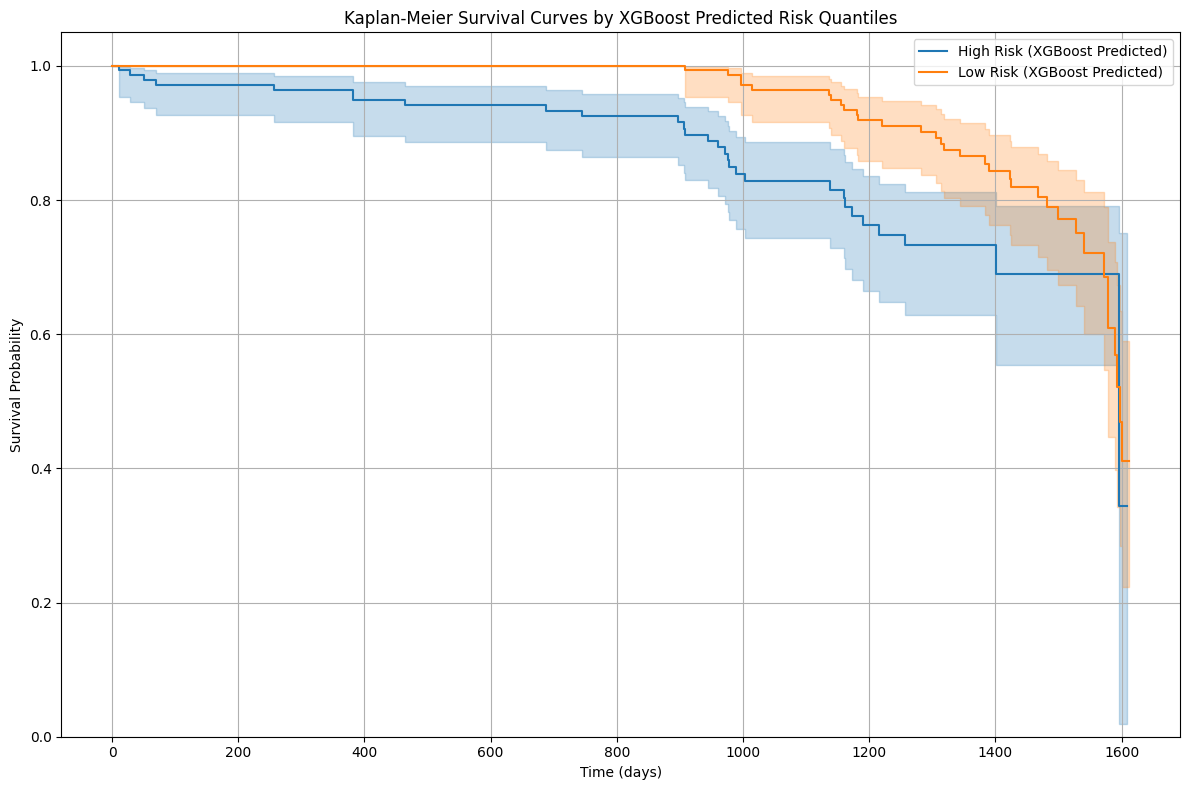

In [18]:
from lifelines import KaplanMeierFitter

# --- 1. Categorize Test Patients into Risk Quantiles based on XGBoost Predictions ---

# Create a DataFrame for test set actual duration and event, aligned with XGBoost predictions
df_test_survival_xgb = pd.DataFrame({
    'duration': y_test.values,
    'event': result_test.values, # 'result_test' was prepared in the previous cell
    'predicted_time_xgb': y_pred_xgb_tuned
}, index=y_test.index)

# Define risk threshold based on predicted_time_xgb median
# Lower predicted time implies higher risk
risk_split_threshold = df_test_survival_xgb['predicted_time_xgb'].median() # Use median for two groups

def assign_xgb_risk_group(predicted_time):
    if predicted_time <= risk_split_threshold:
        return 'High Risk (XGBoost Predicted)'
    else:
        return 'Low Risk (XGBoost Predicted)'

df_test_survival_xgb['xgb_risk_group'] = df_test_survival_xgb['predicted_time_xgb'].apply(assign_xgb_risk_group)

print("XGBoost Predicted Risk Group Distribution:")
print(df_test_survival_xgb['xgb_risk_group'].value_counts())

# --- 2. Calculate and Plot Kaplan-Meier Curves for Each XGBoost Risk Group ---

kmf = KaplanMeierFitter()

plt.figure(figsize=(12, 8))

# Plot K-M curve for each risk group
for name, group_data in df_test_survival_xgb.groupby('xgb_risk_group'):
    kmf.fit(group_data['duration'], event_observed=group_data['event'], label=name)
    kmf.plot_survival_function(ax=plt.gca())

plt.title('Kaplan-Meier Survival Curves by XGBoost Predicted Risk Quantiles')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.ylim(0, 1.05)
plt.legend(loc='best') # Moved legend call here
plt.tight_layout()
plt.show()

### Precision-Recall Curve for XGBoost Risk Classification

To further evaluate the XGBoost model's performance in risk classification, we can plot a Precision-Recall (PR) curve. This curve is particularly useful for imbalanced datasets and focuses on the performance of the positive class ('high_risk' in our case).

Since our XGBoost model is a regressor, we'll treat the predicted 'time' (`y_pred_xgb_tuned`) as a risk score. Given that lower predicted time implies higher risk, we'll invert this score (e.g., by multiplying by -1) so that higher scores correspond to the positive class ('high_risk') as expected by `precision_recall_curve`.

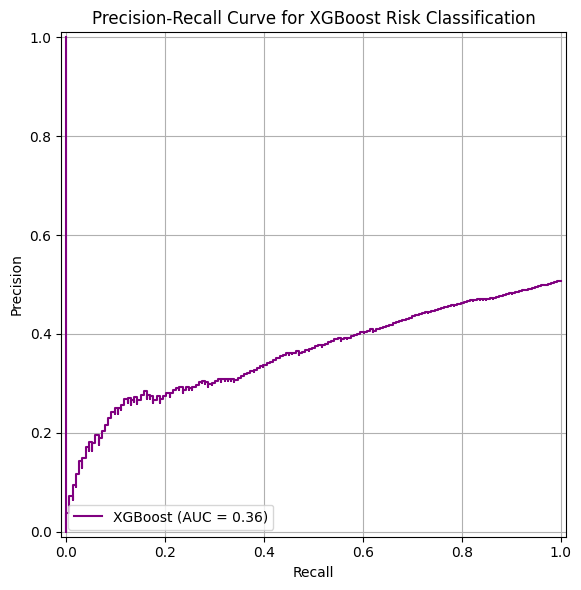

Area Under the Precision-Recall Curve (PR-AUC): 0.3593


In [15]:
from sklearn.metrics import precision_recall_curve, auc, PrecisionRecallDisplay

# 1. Prepare true labels:
# Convert 'low_risk' to 0 and 'high_risk' to 1
y_true_binary = y_test_category_risk.apply(lambda x: 1 if x == 'high_risk' else 0)

# 2. Prepare predicted scores:
# For regression output, lower predicted 'time' means higher risk (positive class).
# We need scores such that higher values indicate the positive class.
# So, we'll use -1 * predicted_time as the score.
# Let's normalize the score to be between 0 and 1 if desired, but raw scores work too.
predicted_scores_for_pr = -1 * y_pred_xgb_tuned

# 3. Compute Precision-Recall curve data
precision, recall, thresholds = precision_recall_curve(y_true_binary, predicted_scores_for_pr)
pr_auc = auc(recall, precision)

# 4. Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
display = PrecisionRecallDisplay(precision=precision, recall=recall, estimator_name="XGBoost Regressor")
display.plot(ax=plt.gca(), name=f'XGBoost (AUC = {pr_auc:.2f})', color='purple')

plt.title('Precision-Recall Curve for XGBoost Risk Classification')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Area Under the Precision-Recall Curve (PR-AUC): {pr_auc:.4f}")
